In [1]:
import pandas as pd

df = pd.read_csv('student_performance_multiclass.csv')

df.head()

,student_id,study_hours,attendance_rate,assignment_score,mock_exam_score,sleep_hours,study_method,course_level,prior_course,performance_class
0,STU0001,5.2,64.8,74.9,56.9,6.4,group_study,basic,0,1
1,STU0002,4.6,88.6,52.0,81.4,8.2,self_study,intermediate,0,1
2,STU0003,5.2,86.2,73.3,75.0,6.0,group_study,advanced,1,1
3,STU0004,6.8,68.2,98.3,76.1,5.6,group_study,intermediate,1,2
4,STU0005,7.2,58.9,62.4,61.9,8.5,academy,basic,1,1


In [2]:
# 전체 행과 열의 개수 확인
df.shape

(360, 10)

In [3]:
# 열의 자료형 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         360 non-null    str    
 1   study_hours        360 non-null    float64
 2   attendance_rate    360 non-null    float64
 3   assignment_score   348 non-null    float64
 4   mock_exam_score    360 non-null    float64
 5   sleep_hours        351 non-null    float64
 6   study_method       353 non-null    str    
 7   course_level       360 non-null    str    
 8   prior_course       360 non-null    int64  
 9   performance_class  360 non-null    int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 28.3 KB


In [4]:
# 결측치 확인
df.isnull().sum()

student_id            0
study_hours           0
attendance_rate       0
assignment_score     12
mock_exam_score       0
sleep_hours           9
study_method          7
course_level          0
prior_course          0
performance_class     0
dtype: int64

In [5]:
# 중복 확인
df.duplicated().sum()

np.int64(0)

In [6]:
# 타깃 클래스 개수 및 비율(normalize=True)
df['performance_class'].value_counts(normalize=True)

performance_class
1    0.527778
0    0.388889
2    0.083333
Name: proportion, dtype: float64

<Axes: xlabel='study_method'>

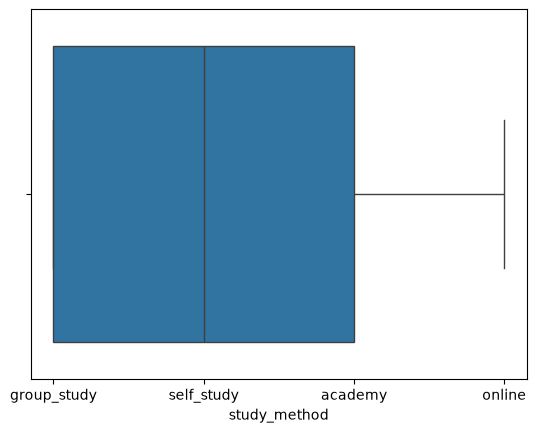

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x=df['study_method'])

In [8]:
df['performance_class'].value_counts()

performance_class
1    190
0    140
2     30
Name: count, dtype: int64

In [9]:
# 두 컬럼 기술 통계량 확인
df[['assignment_score','sleep_hours']].describe()

,assignment_score,sleep_hours
count,348.000000,351.000000
mean,70.783908,6.819943
std,15.082250,1.066021
min,35.000000,4.100000
25%,61.075000,6.100000
50%,71.000000,6.800000
75%,82.200000,7.550000
max,100.000000,9.500000


In [10]:
# 결측치 처리
df['assignment_score'] = df['assignment_score'].fillna(df['assignment_score'].mean())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].mean())

# 결측치 처리 전 최빈값 확인
df['study_method'].mode()[0]

'group_study'

In [11]:
df['study_method'] = df['study_method'].fillna(df['study_method'].mode()[0])

In [12]:
# id 제거 
df.drop(columns=['student_id'], inplace=True)

In [13]:
df = pd.get_dummies(df, columns=['study_method', 'course_level'], dtype=int)

In [14]:
print(df.dtypes)
df.head()

study_hours                  float64
attendance_rate              float64
assignment_score             float64
mock_exam_score              float64
sleep_hours                  float64
prior_course                   int64
performance_class              int64
study_method_academy           int64
study_method_group_study       int64
study_method_online            int64
study_method_self_study        int64
course_level_advanced          int64
course_level_basic             int64
course_level_intermediate      int64
dtype: object


,study_hours,attendance_rate,assignment_score,mock_exam_score,sleep_hours,prior_course,performance_class,study_method_academy,study_method_group_study,study_method_online,study_method_self_study,course_level_advanced,course_level_basic,course_level_intermediate
0,5.2,64.8,74.9,56.9,6.4,0,1,0,1,0,0,0,1,0
1,4.6,88.6,52.0,81.4,8.2,0,1,0,0,0,1,0,0,1
2,5.2,86.2,73.3,75.0,6.0,1,1,0,1,0,0,1,0,0
3,6.8,68.2,98.3,76.1,5.6,1,2,0,1,0,0,0,0,1
4,7.2,58.9,62.4,61.9,8.5,1,1,1,0,0,0,0,1,0


In [15]:
df.isnull().sum()

study_hours                  0
attendance_rate              0
assignment_score             0
mock_exam_score              0
sleep_hours                  0
prior_course                 0
performance_class            0
study_method_academy         0
study_method_group_study     0
study_method_online          0
study_method_self_study      0
course_level_advanced        0
course_level_basic           0
course_level_intermediate    0
dtype: int64

In [16]:
# x,y 분리 / 학습, 테스트 분리
from sklearn.model_selection import train_test_split

x = df.drop(columns=['performance_class'])
y= df['performance_class']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
# 스케일러 적용
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# y_train, y_test 클래스별 개수 확인
print(len(np.unique(y_train)))
print(len(np.unique(y_test)))

3
3


In [29]:
# stratify로 클래스 비율이 유지 됐는지 확인
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())

performance_class
0    0.388889
1    0.527778
2    0.083333
Name: proportion, dtype: float64
performance_class
0    0.388889
1    0.527778
2    0.083333
Name: proportion, dtype: float64


In [30]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)
print(x_train_scaled.shape, x_test_scaled.shape)

(288, 13) (72, 13)
(288,) (72,)
(288, 13) (72, 13)


In [ ]:
# 모델 정의 및 클래스 개수 저장
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

num_classes = len(np.unique(y_train))

model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)), # 컬럼 수 들고와야함
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [50]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# 체크포인트 / 조기 종료
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [53]:
# 모델 학습

history = model.fit(
    x_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


Epoch 1/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 5s 845ms/step - accuracy: 0.4062 - loss: 1.1169
Epoch 1: val_loss improved from None to 1.01787, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3609 - loss: 1.1186 - val_accuracy: 0.4828 - val_loss: 1.0179
Epoch 2/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4062 - loss: 1.0983
Epoch 2: val_loss improved from 1.01787 to 0.94032, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4913 - loss: 1.0149 - val_accuracy: 0.5862 - val_loss: 0.9403
Epoch 3/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5312 - loss: 0.9126
Epoch 3: val_loss improved from 0.94032 to 0.89099, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5522 - loss: 0.9312 - val_accuracy: 0.6034 - val_loss: 0.89

In [54]:
# 현재 모델 평가
test_loss, test_accuracy = model.evaluate(
    x_test_scaled,
    y_test,
)

print('현재 모델 loss :', test_loss)
print('현재 모델 accuracy : ', test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6389 - loss: 0.7620 
현재 모델 loss : 0.7620251774787903
현재 모델 accuracy :  0.6388888955116272


In [55]:
# 저장 모델 평가
from tensorflow.keras.models import load_model

best_model = load_model('best_model.keras')

best_loss, best_accuracy = best_model.evaluate(
    x_test_scaled,
    y_test
)

print('저장 모델 loss :', best_loss)
print('저장 모델 accuracy : ', best_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6389 - loss: 0.7620  
저장 모델 loss : 0.7620251774787903
저장 모델 accuracy :  0.6388888955116272


In [ ]:
# 예측 확률을 클래스로 변환
y_pred_proba = best_model.predict(x_test_scaled)

print(y_pred_proba.shape)
# 클래스 0 확률 1 확률 2 확률
print(y_pred_proba[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
(72, 3)
[[0.03944011 0.9019343  0.05862558]
 [0.67549723 0.32273534 0.00176736]
 [0.21241967 0.7835084  0.0040719 ]
 [0.16995968 0.7986604  0.03137992]
 [0.23406583 0.7636918  0.0022424 ]]


In [58]:
# 가장 높은 확률의 인덱스를 최종 예측 클래스로 선택
# axis=1 이유 = 각 행을 기준으로 가장 큰 값의 위치를 찾는다
y_pred = np.argmax(y_pred_proba, axis=1)

print(y_pred[:10])
print(y_test.iloc[:10].values)

[1 0 1 1 1 1 1 0 1 1]
[2 1 1 1 1 1 1 0 1 1]


In [59]:
# 각 혼동행렬과 평가 보고서
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[19  9  0]
 [ 9 27  2]
 [ 0  6  0]]
              precision    recall  f1-score   support

           0       0.68      0.68      0.68        28
           1       0.64      0.71      0.68        38
           2       0.00      0.00      0.00         6

    accuracy                           0.64        72
   macro avg       0.44      0.46      0.45        72
weighted avg       0.60      0.64      0.62        72



In [ ]:
df['performance_class'].value_counts()
# 현재 2의 데이터 자체가 비율상 적긴 하지만 하나도 못 맞추는 것을 볼 수 있다

performance_class
1    190
0    140
2     30
Name: count, dtype: int64

In [ ]:
# 클래스 가중치 계산 